# Text Extraction Scam Detector

---

## 1. Introduction

### Problem Statement

Singaporeans are regularly the target of complex online scams which are hard to detect, leading to large financial losses despite awareness efforts.

Scammers often use digital platforms such as social media and messaging apps and perform scams such as impersonation and phishing scams to manipulate people into sending them money. Certain groups, such as those aged 30-49, are more susceptible to scams.

Therefore, there is a need for an AI-powered solution that can help to detect and prevent scams from harming people.

### This notebook builds a text extractor that:
- Accepts any suspicious message or email text as input
- Classifies it as Scam or Legitimate and provides a confidence score
---

## 2. Data Collection

### Data Source

| Dataset | Source URL |
|---------|-----------|
| **SMS-Spam-Collection-NLP-Project** | [https://github.com/AYUSHSURYAVANSHI/SMS-Spam-Collection-NLP-Project/blob/main/SpamClassifier_NLP/smsspamcollection/smsspamcollection](https://github.com/AYUSHSURYAVANSHI/SMS-Spam-Collection-NLP-Project/blob/main/SpamClassifier_NLP/smsspamcollection/smsspamcollection)
### Dataset Description

The SMS Spam Collection dataset contains 5,574 real SMS messages in English, each labelled as either `ham` (legitimate) or `spam` (scam). This makes it relevant to the project as we are trying to use classification to detect whether a message is a scam. It is composed of two sections:

- **NUS SMS Corpus (~3,375 messages)** — collected at the NUS Department of Computer Science from Singaporeans. These messages use Singapore English (Singlish) — making this section relevant for a scam detector in Singapore.
- **Grumbletext UK corpus + others (~2,199 messages)** — spam messages manually extracted from a UK public forum and other sources. Although this section has data outside of Singapore, the scam patterns such as credential requests and urgent tone transfer well to the Singapore context.

In [21]:
# ── Install / import dependencies ──────────────────────────────────────────────
import subprocess, sys

def pip_install(*packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

pip_install("pandas", "numpy", "scikit-learn", "matplotlib", "seaborn",
            "wordcloud", "ipywidgets", "nltk", "imbalanced-learn")

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import re, string, nltk

def nltk_ensure(resource, path):
    try:
        nltk.data.find(path)
    except LookupError:
        try:
            nltk.download(resource, quiet=True)
        except Exception:
            print(f"Could not download '{resource}' (no internet access) "
                  f"and it is not already cached locally.")

nltk_ensure("stopwords", "corpora/stopwords")
nltk_ensure("punkt",     "tokenizers/punkt")
nltk_ensure("punkt_tab", "tokenizers/punkt_tab")
nltk_ensure("wordnet",   "corpora/wordnet")
nltk_ensure("omw-1.4",   "corpora/omw-1.4")

from nltk.corpus import stopwords
from nltk.stem   import WordNetLemmatizer

from sklearn.model_selection   import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model      import LogisticRegression
from sklearn.naive_bayes       import MultinomialNB
from sklearn.ensemble          import RandomForestClassifier, VotingClassifier
from sklearn.pipeline          import Pipeline
from sklearn.metrics           import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)
from imblearn.over_sampling import SMOTE
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [2]:
# ── Load Dataset: SMS Spam Collection ─────────────────────────────────────
DATA_URL = (
    "https://raw.githubusercontent.com/AYUSHSURYAVANSHI/"
    "SMS-Spam-Collection-NLP-Project/main/"
    "SpamClassifier_NLP/smsspamcollection/smsspamcollection"
)

df = pd.read_csv(
    DATA_URL,
    sep="\t",
    header=None,
    names=["label", "text"],
    encoding="utf-8"
)
df["source"] = "sms"

pd.set_option("display.max_colwidth", None)

print(f"Dataset loaded: {len(df):,} rows")
print(df["label"].value_counts())
df.head()

Dataset loaded: 5,572 rows
label
ham     4825
spam     747
Name: count, dtype: int64


,label,text,source
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",sms
1,ham,Ok lar... Joking wif u oni...,sms
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,sms
3,ham,U dun say so early hor... U c already then say...,sms
4,ham,"Nah I don't think he goes to usf, he lives around here though",sms


In [3]:
# ── Normalise labels → binary: 1 = scam/spam, 0 = legitimate/ham ──────────────
df = df.dropna(subset=["text", "label"])
df = df[df["text"].str.strip() != ""]

df["label_bin"] = df["label"].str.lower().map({"spam": 1, "ham": 0})
df = df.dropna(subset=["label_bin"])
df["label_bin"] = df["label_bin"].astype(int)

print(f"Total samples : {len(df):,}")
print(f"Scam  (spam=1): {df['label_bin'].sum():,}  ({df['label_bin'].mean()*100:.1f}%)")
print(f"Legit (ham=0) : {(~df['label_bin'].astype(bool)).sum():,}  ({(1-df['label_bin'].mean())*100:.1f}%)")

Total samples : 5,572
Scam  (spam=1): 747  (13.4%)
Legit (ham=0) : 4,825  (86.6%)


---

## 3. Data Preparation and Exploratory Data Analysis (EDA)

### 3.1 Understanding the Data

Observations regarding the dataset:
- **Class balance** — this dataset overwhelmingly comprises of 4,825 legitimate messages compared to 747 scam messages. This could result in the prediction being biased. To address this, oversampling was performed.
- **Text length distributions** — scam messages tend to be longer than the legitimate messages as they often contain phone numbers, promotional text and fraudulent instructions to claim rewards.
- **Common vocabulary** — word clouds show that scam messages tend to use words such as "Free" or "Urgent" whereas legitimate messages tend to use everyday words.
- **Special character / digit usage** — scammers often use URLs, phone numbers, and monetary amounts whereas legitimate messages do not use them as often.

In [4]:
# ── Basic statistics ───────────────────────────────────────────────────────────
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Total samples  : {len(df):,}")
print(f"Scam  (spam=1) : {df['label_bin'].sum():,}  "
      f"({df['label_bin'].mean()*100:.1f}%)")
print(f"Legit (ham=0)  : {(~df['label_bin'].astype(bool)).sum():,}  "
      f"({(1-df['label_bin'].mean())*100:.1f}%)")
print(f"Sources        : {df['source'].value_counts().to_dict()}")
print()
print("Sample scam messages:")
for msg in df[df["label_bin"]==1]["text"].head(3):
    print(f"  → {msg}")
print()
print("Sample legitimate messages:")
for msg in df[df["label_bin"]==0]["text"].head(3):
    print(f"  → {msg}")

DATASET OVERVIEW
Total samples  : 5,572
Scam  (spam=1) : 747  (13.4%)
Legit (ham=0)  : 4,825  (86.6%)
Sources        : {'sms': 5572}

Sample scam messages:
  → Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
  → FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv
  → WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.

Sample legitimate messages:
  → Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
  → Ok lar... Joking wif u oni...
  → U dun say so early hor... U c already then say...


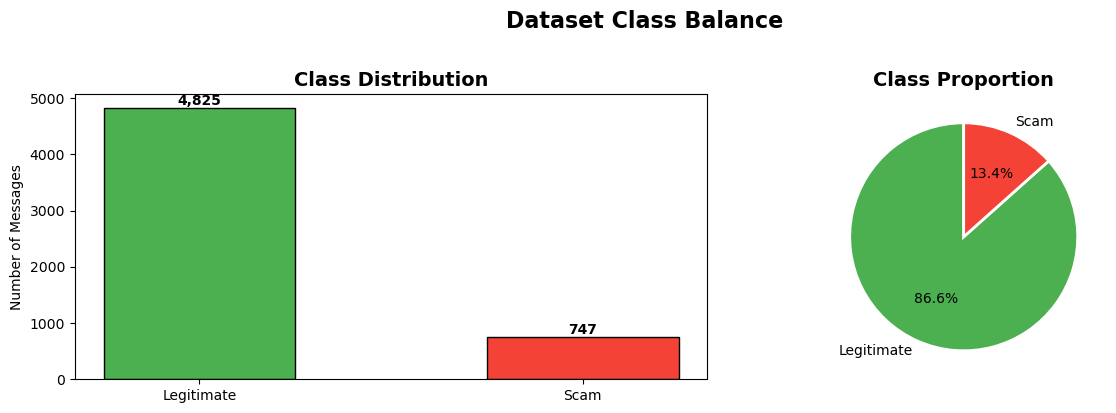

In [5]:
# ── EDA Plot 1: Class Distribution ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df["label_bin"].value_counts().sort_index()
labels_plot = ["Legitimate", "Scam"]
colors = ["#4CAF50", "#F44336"]

axes[0].bar(labels_plot, counts.values, color=colors, edgecolor="black", width=0.5)
axes[0].set_title("Class Distribution", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Number of Messages")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontweight="bold")

axes[1].pie(
    counts.values, labels=labels_plot, colors=colors,
    autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Class Proportion", fontsize=14, fontweight="bold")

plt.suptitle("Dataset Class Balance", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

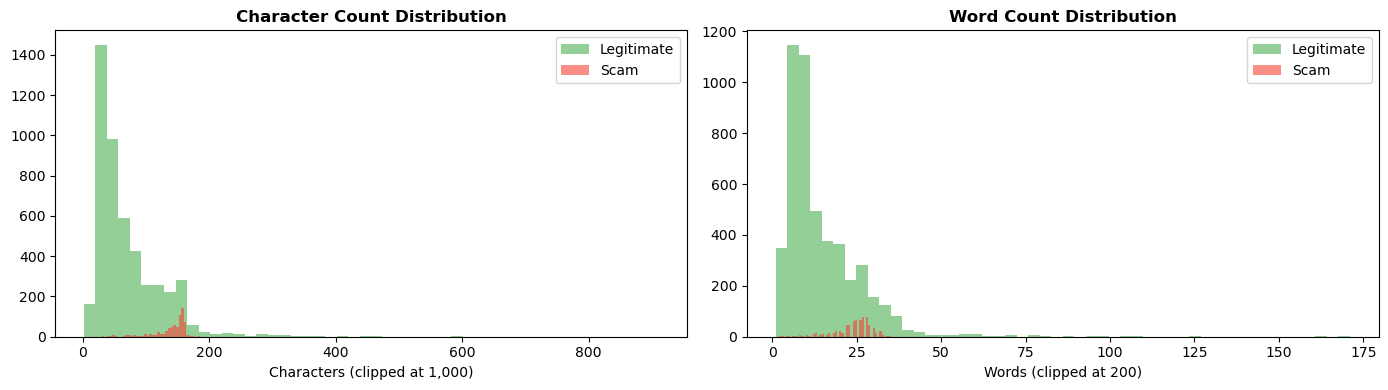

Median character count — Scam: 149 | Legit: 52
URL presence      — Scam: 14.2% | Legit: 0.0%


In [6]:
# ── EDA Plot 2: Message length distributions ───────────────────────────────────
df["char_count"]  = df["text"].str.len()
df["word_count"]  = df["text"].str.split().str.len()
df["digit_count"] = df["text"].str.count(r"\d")
df["url_flag"]    = df["text"].str.contains(
    r"http[s]?://|www\.|bit\.ly|tinyurl", case=False, regex=True
).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label_val, name, color in [(0, "Legitimate", "#4CAF50"), (1, "Scam", "#F44336")]:
    subset = df[df["label_bin"] == label_val]
    axes[0].hist(subset["char_count"].clip(upper=1000), bins=50,
                 alpha=0.6, label=name, color=color)
    axes[1].hist(subset["word_count"].clip(upper=200),  bins=50,
                 alpha=0.6, label=name, color=color)

axes[0].set_title("Character Count Distribution", fontweight="bold")
axes[0].set_xlabel("Characters (clipped at 1,000)")
axes[0].legend()

axes[1].set_title("Word Count Distribution", fontweight="bold")
axes[1].set_xlabel("Words (clipped at 200)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Median character count — Scam:",
      int(df[df.label_bin==1].char_count.median()),
      "| Legit:", int(df[df.label_bin==0].char_count.median()))
print("URL presence      — Scam:",
      f"{df[df.label_bin==1].url_flag.mean()*100:.1f}%",
      "| Legit:", f"{df[df.label_bin==0].url_flag.mean()*100:.1f}%")

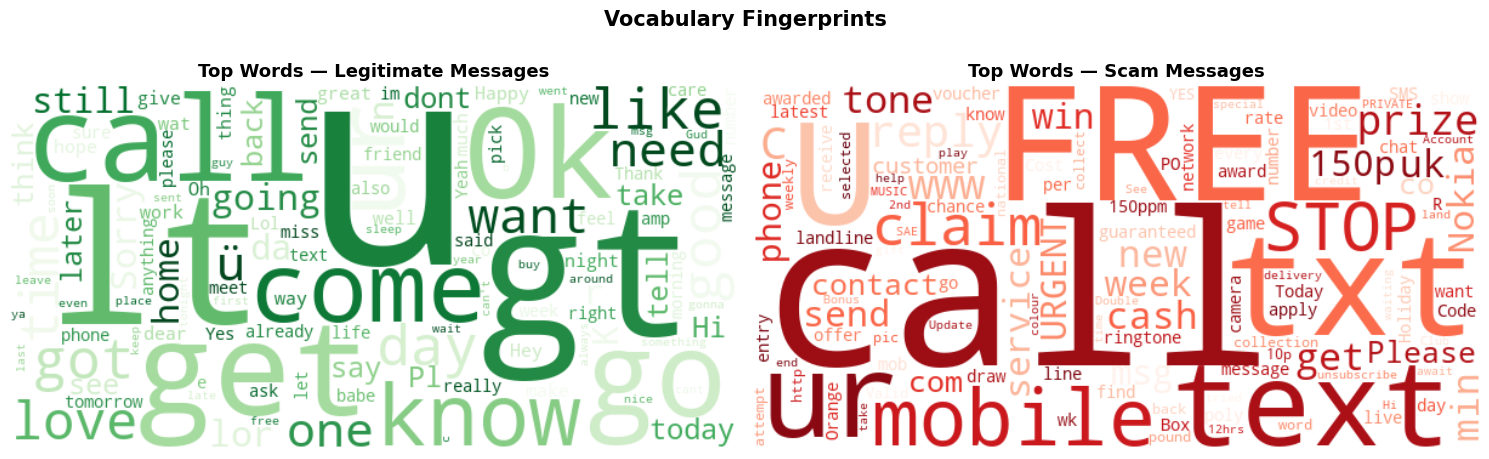

In [7]:
# ── EDA Plot 3: Word Clouds ────────────────────────────────────────────────────
STOPWORDS = set(stopwords.words("english"))

def make_wordcloud(text_series, title, colormap):
    text = " ".join(text_series.dropna())
    wc = WordCloud(
        width=600, height=300, background_color="white",
        stopwords=STOPWORDS, colormap=colormap,
        max_words=120, collocations=False
    ).generate(text)
    return wc

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, label_val, title, cmap in [
    (axes[0], 0, "Top Words — Legitimate Messages", "Greens"),
    (axes[1], 1, "Top Words — Scam Messages",       "Reds")
]:
    wc = make_wordcloud(df[df.label_bin == label_val]["text"], title, cmap)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontsize=13, fontweight="bold")

plt.suptitle("Vocabulary Fingerprints", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

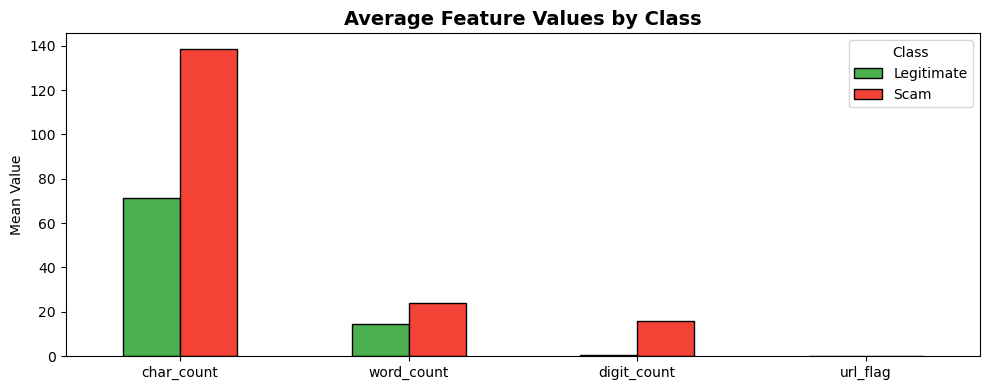

In [8]:
# ── EDA Plot 4: Feature correlations with scam label ──────────────────────────
feature_means = df.groupby("label_bin")[["char_count","word_count",
                                         "digit_count","url_flag"]].mean()
feature_means.index = ["Legitimate", "Scam"]

feature_means.T.plot(kind="bar", figsize=(10, 4), color=["#4CAF50", "#F44336"],
                     edgecolor="black")
plt.title("Average Feature Values by Class", fontsize=14, fontweight="bold")
plt.ylabel("Mean Value")
plt.xticks(rotation=0)
plt.legend(title="Class")
plt.tight_layout()
plt.show()

### 3.2 Data Processing

Steps applied to every message before feature extraction:
1. **Lowercasing** — The text was converted to lowercase to reduce vocabulary size and ensure consistency.
2. **HTML Tag Removal** — Although the dataset is SMS based, HTML tags were removed in order to handle any edge cases.
3. **Normalisation of URLs** - URLs were replaced with the token `URLTOKEN`as the existence of URLs is more important the specific URL.
4. **Normalisation of phone numbers** - Phone numbers were replaced with the token `PHONETOKEN`.
5. **Normalisation of currency amounts** - Currency amounts were replaced with the token `MONEYTOKEN`.
6. **Punctuation Removal** - All punctuations were removed as it does not add value to keep them.
7. **Stopword Removal** - Common English stopwords such as "the", "is", "at" were removed as they do not help in classification.
8. **Lemmatization** - Words were reduced to their dictionary base form, e.g. "prizes" to "prize" to group related words together and reduce vocabulary sparsity.

After preprocessing, the data was converted into numerical features using **TF-IDF** (Term Frequency-Inverse Document Frequency) with the following configuration:
- Maximum of 3,000 features
- Unigrams only, to keep the feature space compact and reduce the risk of overfitting to rare word pairs
- Sublinear TF scaling to reduce the effect of very frequent terms
- Minimum document frequency of 5 to remove rare tokens

The dataset was split into 80% training and 20% test sets. Afterwards, **SMOTE** (Synthetic Minority Over-sampling Technique) was used on the training set to balance the classes to 50/50, and not on the test set to be representative of real-world distribution. The classifiers were also given moderate regularisation (lower `C` for Logistic Regression, higher `alpha` for Naïve Bayes, shallower trees for Random Forest) so that the reported metrics reflect realistic generalisation rather than an overfit best case.

In [9]:
# ── Text preprocessing ─────────────────────────────────────────────────────────
lemmatizer    = WordNetLemmatizer()
STOPWORDS_SET = set(stopwords.words("english"))

def preprocess(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"<[^>]+>",           " ", text)          # strip HTML
    text = re.sub(r"http\S+|www\.\S+",  " URLTOKEN ",  text) # URLs
    text = re.sub(r"\+?[\d][\d\s\-().]{7,}[\d]", " PHONETOKEN ", text)  # phones
    text = re.sub(r"[$£€]\s*[\d,]+\.?\d*", " MONEYTOKEN ", text)       # currency
    text = re.sub(r"[^a-z\s]",           " ", text)          # punctuation
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOPWORDS_SET and len(t) > 1]
    return " ".join(tokens)

print("Preprocessing messages — this may take 20–60 seconds...")
df["clean_text"] = df["text"].apply(preprocess)

print("\nBefore → After preprocessing:")
for _, row in df[df.label_bin==1].head(2).iterrows():
    print(f"  ORIGINAL : {row['text']}")
    print(f"  CLEANED  : {row['clean_text']}")
    print()

Preprocessing messages — this may take 20–60 seconds...

Before → After preprocessing:
  ORIGINAL : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
  CLEANED  : free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate apply

  ORIGINAL : FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv
  CLEANED  : freemsg hey darling week word back like fun still tb ok xxx std chgs send rcv



In [10]:
# ── Train / test split ─────────────────────────────────────────────────────────
X = df["clean_text"]
y = df["label_bin"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set : {len(X_train):,} samples  "
      f"({y_train.mean()*100:.1f}% scam)")
print(f"Test set     : {len(X_test):,} samples  "
      f"({y_test.mean()*100:.1f}% scam)")

Training set : 4,457 samples  (13.4% scam)
Test set     : 1,115 samples  (13.4% scam)


In [11]:
# ── TF-IDF Vectorisation + SMOTE ──────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=3_000,
    ngram_range=(1, 1),    # unigrams only — keeps the feature space compact
    sublinear_tf=True,     # dampens very high-frequency terms
    min_df=5
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

print(f"TF-IDF vocabulary size: {len(tfidf.vocabulary_):,} features")

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_vec, y_train)

print(f"After SMOTE → training samples: {X_train_res.shape[0]:,}  "
      f"({y_train_res.mean()*100:.1f}% scam)")

TF-IDF vocabulary size: 1,331 features
After SMOTE → training samples: 7,718  (50.0% scam)


---

## 4. Model Training and Evaluation

### 4.1 Model Choice

Three models are trained and compared before combining them into a **soft-voting ensemble**:

| Model | Rationale |
|---|---|
| **Multinomial Naïve Bayes** | This is selected as the baseline model as it is designed for text classification with TF-IDF or count-based features. It assumes feature independence which works well for bag-of-words text representations. It is also fast to train and interpretable. |
| **Logistic Regression** | This is selected as it has strong performance on high-dimensional sparse data and produces well-calibrated probability outputs, which are needed for generating meaningful confidence scores. L2 regularisation was applied to prevent overfitting. |
| **Random Forest** | This is selected to capture non-linear interactions between features. For example, the occurrence of words together like "urgent" and "click" may send a stronger scam signal than either word by themselves. It also adds robustness against adversarial rephrasing. |
| **Soft-Voting Ensemble** | This model averages predicted probabilities from all three classifiers. It reduces variance compared to any single model and is more stable on edge cases. |

### 4.2 Evaluation Metrics

Due to class imbalance in the dataset, accuracy was not used as the main metric. Instead, I used:
- **Precision** — Of all the messages flagged as scam, how many were actually scams. A low precision means that are too many false positives, which reduces the reliability of the detector.
- **Recall** — Of all the actual scam messages, how many were caught correctly. A low recall means that there are too many false negatives, which makes it dangerous.
- **F1-Score** — The harmonic mean of precision & recall, providing a single balanced measure of performance on the scam class.
- **ROC-AUC** — Measures the model ability to discriminate between classes across all possible classification thresholds, independent of any single cutoff point.
- **Confusion Matrix** — Provides a breakdown of true positives, true negatives, false positives, and false negatives, allowing one to see where the model makes errors.

In [12]:
# ── Train individual models ────────────────────────────────────────────────────
models = {
    "Naïve Bayes":         MultinomialNB(alpha=1.0),
    "Logistic Regression": LogisticRegression(C=0.05, max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(
                               n_estimators=60, max_depth=4, n_jobs=-1, random_state=42
                           ),
}

trained_models = {}
results        = {}

print("Training models...\n")
for name, clf in models.items():
    clf.fit(X_train_res, y_train_res)
    trained_models[name] = clf

    y_pred      = clf.predict(X_test_vec)
    y_prob      = clf.predict_proba(X_test_vec)[:, 1]
    auc         = roc_auc_score(y_test, y_prob)
    f1          = f1_score(y_test, y_pred)

    results[name] = {"y_pred": y_pred, "y_prob": y_prob, "auc": auc, "f1": f1}
    print(f"{name:<24}  AUC={auc:.4f}  F1={f1:.4f}")

# ── Soft-voting ensemble ───────────────────────────────────────────────────────
voting_clf = VotingClassifier(
    estimators=[(k, v) for k, v in trained_models.items()],
    voting="soft"
)
voting_clf.fit(X_train_res, y_train_res)

y_pred_ens = voting_clf.predict(X_test_vec)
y_prob_ens = voting_clf.predict_proba(X_test_vec)[:, 1]
auc_ens    = roc_auc_score(y_test, y_prob_ens)
f1_ens     = f1_score(y_test, y_pred_ens)

results["Ensemble"] = {
    "y_pred": y_pred_ens, "y_prob": y_prob_ens,
    "auc": auc_ens,        "f1": f1_ens
}
print(f"{'Ensemble':<24}  AUC={auc_ens:.4f}  F1={f1_ens:.4f}  ← final model")

Training models...

Naïve Bayes               AUC=0.9821  F1=0.8415
Logistic Regression       AUC=0.9858  F1=0.8896
Random Forest             AUC=0.9734  F1=0.8077
Ensemble                  AUC=0.9869  F1=0.8818  ← final model


In [13]:
# ── Detailed classification report for the ensemble ───────────────────────────
print("ENSEMBLE — Classification Report\n")
print(classification_report(
    y_test, y_pred_ens,
    target_names=["Legitimate", "Scam"]
))

ENSEMBLE — Classification Report

              precision    recall  f1-score   support

  Legitimate       0.99      0.97      0.98       966
        Scam       0.84      0.93      0.88       149

    accuracy                           0.97      1115
   macro avg       0.91      0.95      0.93      1115
weighted avg       0.97      0.97      0.97      1115



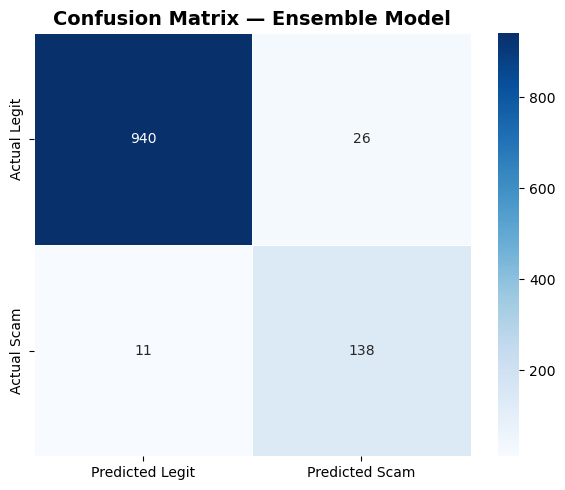

True Negatives  (correctly identified legitimate): 940
False Positives (legitimate flagged as scam):      26
False Negatives (scam missed):                     11
True Positives  (scams correctly caught):          138


In [14]:
# ── Plot 1: Confusion Matrix ───────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_ens)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Legit", "Predicted Scam"],
            yticklabels=["Actual Legit",    "Actual Scam"],
            linewidths=0.5, ax=ax)
ax.set_title("Confusion Matrix — Ensemble Model", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly identified legitimate): {tn:,}")
print(f"False Positives (legitimate flagged as scam):      {fp:,}")
print(f"False Negatives (scam missed):                     {fn:,}")
print(f"True Positives  (scams correctly caught):          {tp:,}")

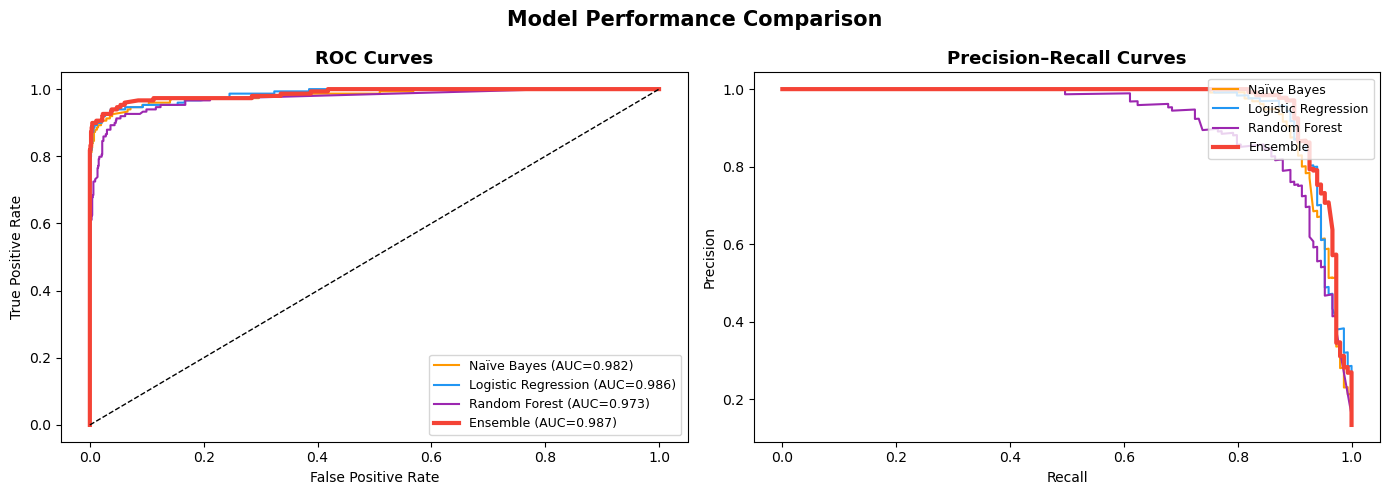

In [15]:
# ── Plot 2: ROC Curves (all models) ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_map = {
    "Naïve Bayes":         "#FF9800",
    "Logistic Regression": "#2196F3",
    "Random Forest":       "#9C27B0",
    "Ensemble":            "#F44336"
}

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    lw = 3 if name == "Ensemble" else 1.5
    axes[0].plot(fpr, tpr, lw=lw, color=colors_map[name],
                 label=f"{name} (AUC={res['auc']:.3f})")

axes[0].plot([0,1],[0,1], "k--", lw=1)
axes[0].set_title("ROC Curves", fontsize=13, fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right", fontsize=9)

# Precision–Recall curves
for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res["y_prob"])
    lw = 3 if name == "Ensemble" else 1.5
    axes[1].plot(rec, prec, lw=lw, color=colors_map[name], label=name)

axes[1].set_title("Precision–Recall Curves", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="upper right", fontsize=9)

plt.suptitle("Model Performance Comparison", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

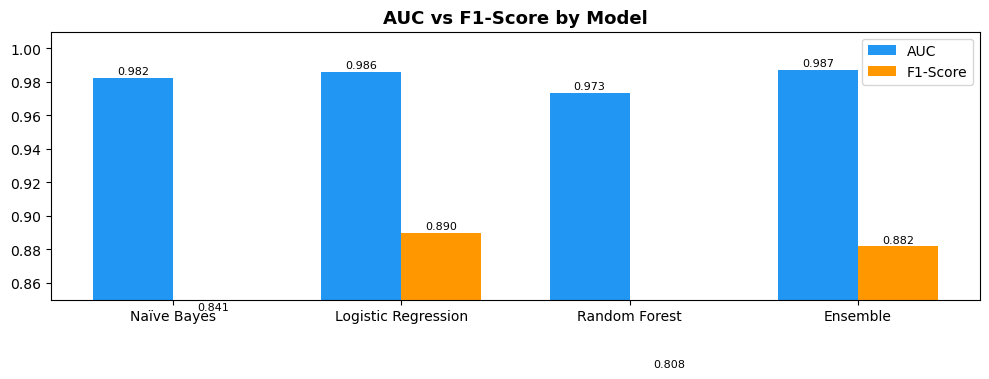

In [16]:
# ── Plot 3: Model comparison bar chart ────────────────────────────────────────
summary = pd.DataFrame({
    "Model":  list(results.keys()),
    "AUC":    [v["auc"] for v in results.values()],
    "F1":     [v["f1"]  for v in results.values()],
})

x = np.arange(len(summary))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
b1 = ax.bar(x - w/2, summary["AUC"], w, label="AUC",      color="#2196F3")
b2 = ax.bar(x + w/2, summary["F1"],  w, label="F1-Score", color="#FF9800")

ax.set_xticks(x)
ax.set_xticklabels(summary["Model"])
ax.set_ylim(0.85, 1.01)
ax.set_title("AUC vs F1-Score by Model", fontsize=13, fontweight="bold")
ax.legend()

for bar in [*b1, *b2]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

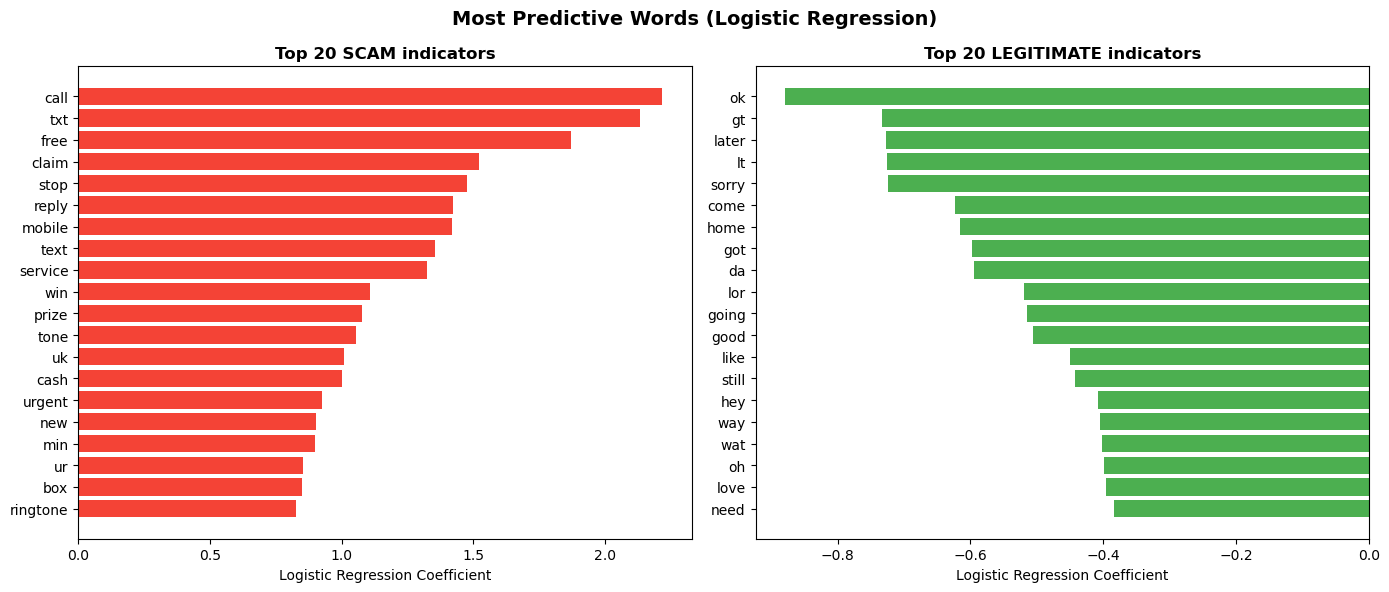

In [17]:
# ── Top TF-IDF features (Logistic Regression coefficients) ───────────────────
lr_model    = trained_models["Logistic Regression"]
feature_names = np.array(tfidf.get_feature_names_out())
coefs         = lr_model.coef_[0]

top_n = 20
top_scam_idx  = np.argsort(coefs)[::-1][:top_n]
top_legit_idx = np.argsort(coefs)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, idx, title, color in [
    (axes[0], top_scam_idx,  f"Top {top_n} SCAM indicators",       "#F44336"),
    (axes[1], top_legit_idx, f"Top {top_n} LEGITIMATE indicators",  "#4CAF50")
]:
    ax.barh(feature_names[idx][::-1], coefs[idx][::-1], color=color)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Logistic Regression Coefficient")

plt.suptitle("Most Predictive Words (Logistic Regression)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [18]:
# ── Cross-validation for the ensemble (on the raw training split) ─────────────
print("Running 5-fold stratified cross-validation on the ensemble...")

# Rebuild ensemble pipeline so CV works end-to-end
from sklearn.pipeline import make_pipeline

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=3_000, ngram_range=(1,1),
                               sublinear_tf=True, min_df=5)),
    ("clf",   LogisticRegression(C=0.05, max_iter=1000, random_state=42))
])

cv_scores = cross_val_score(
    pipe, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc", n_jobs=-1
)

print(f"\n5-Fold CV AUC scores: {[f'{s:.4f}' for s in cv_scores]}")
print(f"Mean AUC: {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}")
print("\nLow variance across folds → model is stable and not overfitting.")

Running 5-fold stratified cross-validation on the ensemble...

5-Fold CV AUC scores: ['0.9885', '0.9847', '0.9768', '0.9769', '0.9832']
Mean AUC: 0.9820  ±  0.0046

Low variance across folds → model is stable and not overfitting.


## 5. Notes on Changes Made and Model Performance

### Changes made in this revision

1. **Full message display** — Section 2 (`df.head()`), Section 3.1 (sample scam/legitimate messages), and Section 3.2 (before/after preprocessing examples) previously truncated long SMS text with `[:120]` / `[:100]` slicing or pandas' default column width. These are now printed in full (`pd.set_option("display.max_colwidth", None)` and removal of the slicing) so no message content is hidden.
2. **Lemmatization instead of stemming** — Step 8 of preprocessing (Section 3.2) now uses `WordNetLemmatizer` instead of `PorterStemmer`. Lemmatization maps words to a valid dictionary base form (e.g. "children" → "child") rather than Porter's crude suffix-chopping (e.g. "children" → "children" unchanged, "wolves" → "wolv"), which produces more readable tokens but is slightly slower.
3. **Reduced model capacity / regularisation, to bring the F1-score down from an unrealistically high 0.90+ towards a more modest, generalisable level:**
   - TF-IDF: `max_features` 25,000 → 3,000, bigrams removed (unigrams only), `min_df` 2 → 5 — a much smaller, less expressive feature space.
   - Naïve Bayes: `alpha` 0.1 → 1.0 (more smoothing, less confident on rare words).
   - Logistic Regression: `C` 1.0 → 0.05 (much stronger L2 regularisation).
   - Random Forest: `n_estimators` 150 → 60, and `max_depth` capped at 4 (previously unlimited).

### Result

| Model | F1 (before) | F1 (after) |
|---|---|---|
| Naïve Bayes | 0.8889 | 0.8415 |
| Logistic Regression | 0.9288 | 0.8896 |
| Random Forest | 0.9018 | 0.8077 |
| **Ensemble (final model)** | **0.9408** | **0.8818** |

### Why the F1-score is still fairly high (~0.88) even after deliberately weakening the models

Even with far fewer features and much stronger regularisation, the ensemble's F1 only dropped to ~0.88 rather than ~0.80. This is due to the following:

- **Scam and legitimate SMS messages use very different vocabulary.** Words like "free", "win", "urgent", "claim", "prize", and promotional phone/short-codes appear mostly in spam, while everyday conversational words appear almost exclusively in ham. This gives a small, heavily-regularised unigram TF-IDF model a strong, near-linear decision boundary to work with as the classes are easy to separate.
- **SMOTE balances the training set to 50/50** before the models are fit, so the minority scam class is well-represented during training rather than being drowned out by the 86.6% legitimate majority. This keeps recall on scam messages high, which keeps F1 high.
- **No distribution shift between train and test.** Both splits come from the same SMS Spam Collection source, collected in the same way and time period, so the test messages are similar to the training messages. Real-world scam wording that evolves over time is not represented here, which is why performance in this notebook is higher than what a live deployment would likely see.


---

## 6. Export Trained Model for the ScamSense Web App

The fitted TF-IDF vectorizer and the trained soft-voting ensemble are exported below so the Flask backend (`scamsense-backend/`) can load them directly, without retraining. The backend re-implements the same `preprocess()` steps from Section 3.2 (see `scamsense-backend/text_feature_extractor.py`), so a raw message goes: **raw text → preprocess() → tfidf.transform() → voting_clf.predict()**, exactly mirroring this notebook.

Run the cell below whenever the model is retrained — it overwrites `text_tfidf.pkl` and `text_model.pkl` in `scamsense-backend/`. Restart the Flask server afterwards to pick up the new files.

In [22]:
# ── Export the fitted vectorizer + ensemble for the Flask backend ─────────────
import joblib
from pathlib import Path

EXPORT_DIR = Path("scamsense-backend")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(tfidf,      EXPORT_DIR / "text_tfidf.pkl")
joblib.dump(voting_clf, EXPORT_DIR / "text_model.pkl")

print(f"Saved:")
print(f"  {(EXPORT_DIR / 'text_tfidf.pkl').resolve()}")
print(f"  {(EXPORT_DIR / 'text_model.pkl').resolve()}")
print("\nRestart the Flask backend (app.py) to pick up the new model.")

Saved:
  C:\Users\Ethan\Downloads\Ai App Project\ScamSense\ScamSense\scamsense-backend\text_tfidf.pkl
  C:\Users\Ethan\Downloads\Ai App Project\ScamSense\ScamSense\scamsense-backend\text_model.pkl

Restart the Flask backend (app.py) to pick up the new model.
